In [72]:
import numpy as np
from farm.plant import Plant
from farm import Climate
from farm import Soil
from farm import Crop
from farm import CropModel
import pandas as pd
from pandas import DataFrame
from numpy import zeros
import matplotlib.pyplot as plt

In [73]:
class Tree(Plant):
    """
    Very simple tree:
    - constant kc (make it seasonal later)
    - deeper roots, higher T_MAX
    - same piecewise linear T(s) idea as Crop
    """
    def __init__(self, kc=1.0, LAI_max=2.0, *args, **kwargs):
        self.kc = kc
        self.LAI_max = LAI_max
        super().__init__(*args, **kwargs)

    def calc_LAI(self):
        return self.LAI_max

    def calc_I(self, LAI=None, int_efficiency=0.5):
        """
        Simple interception.
        Trees intercept rainfall but we keep it conservative.
        """
        LAI_use = self.LAI if LAI is None else LAI
        return LAI_use * int_efficiency

    def calc_T(self, s, LAI=None, kc=None):
        kc_use = self.kc if kc is None else kc

        if s >= self.s_star:
            return kc_use * self.T_MAX
        elif s >= self.sw:
            return (s - self.sw) / (self.s_star - self.sw) * (kc_use * self.T_MAX)
        else:
            return 0.0


In [74]:
def shade_factor(LAI_tree, k_shade=0.3):
    """
    Fraction of incoming energy available for evaporation/transpiration.

    LAI_tree : tree leaf area index
    k_shade  : shading efficiency [−]

    Returns value in (0, 1].
    """
    return np.exp(-k_shade * LAI_tree)


In [ ]:
# old (2.12.2026)
class TreeCropModel:
    def __init__(self, soil=None, climate=None, crop=None, tree=None):
        self.soil = soil
        self.crop = crop
        self.tree = tree
        self.climate = climate

        # IMPORTANT: use deeper rooting depth for the shared bucket storage.
        # This is the simplest "one bucket" competition assumption.
        class _Tmp: pass
        tmp = _Tmp()
        tmp.Zr = max(self.crop.Zr, self.tree.Zr)
        self.nZr = soil.set_nZr(tmp)

        # self.nZr = soil.set_nZr(self.crop) # DELETE SOON


    def pre_allocate(self):
        self.R = zeros(self.n_days)
        self.s = zeros(self.n_days + 1)   # NOTE: needs n_days+1 because s[t+1]
        self.ET = zeros(self.n_days)
        self.I = zeros(self.n_days)
        self.E = zeros(self.n_days)
        self.T = zeros(self.n_days)
        self.L = zeros(self.n_days)
        self.Q = zeros(self.n_days)
        self.dos = zeros(self.n_days)
        self.dsdt = zeros(self.n_days)
        self.LAI = zeros(self.n_days)
        self.kc = zeros(self.n_days)
        self.stress = zeros(self.n_days)

        # --- NEW: tree + split ET outputs ---
        self.T_tree = zeros(self.n_days)
        self.ET_crop = zeros(self.n_days)
        self.ET_tree = zeros(self.n_days)

    def run(self, do_output=False, s0=0.3, planting_date=100, t_before=60, t_after=7):
        self.planting_date = planting_date
        self.n_days = t_before + self.crop.lgp + t_after
        self.pre_allocate()

        self.doy_start = self.planting_date - t_before
        if self.doy_start <= 0:
            self.doy_start = 365 + self.doy_start

        doy = np.arange(self.doy_start, self.doy_start + self.n_days)
        while (doy - 365 > 0).any():
            doy = doy - 365 * ((doy - 365) > 0)

        for t in range(self.n_days):
            self.R[t] = self.climate.rainfall[doy[t]-1]
        self.doy = doy

        self.s[0] = s0

        dos = 0
        planted = False

        for t in range(self.n_days):
            # Determine DOS
            if self.doy[t] == self.planting_date:
                planted = True
            if planted:
                dos += 1

            self.dos[t] = dos

            # Crop phenology (same as maize model)
            self.kc[t] = self.crop.calc_kc(dos)

            # NOTE: changed original line from self.kc[dos] to self.kc[t].
            self.LAI[t] = self.crop.calc_LAI(self.kc[t])

            self.stress[t] = self.crop.calc_stress(self.s[t])

            # Runoff based on current s
            self.Q[t] = self.soil.calc_Q(self.s[t], units="mm/day")

            # ---- Water balance part 1 (same structure)
            # Interception: keep only crop interception for now (simple)
            self.I[t] = min(self.crop.calc_I(self.LAI[t]), self.R[t])
            rainfall = max(self.R[t] - self.I[t], 0.0)

            _dsdt = rainfall - self.Q[t]   # mm/day
            _s = self.s[t] + _dsdt / self.nZr

            # ---- NEW: tree "drinks first" from _s
            # self.T_tree[t] = self.tree.calc_T(_s)

            # # Convert that flux to a reduction in relative saturation for crop calculation.
            # # This is the simplest shared-bucket priority rule.
            # _s_after_tree = _s - (self.T_tree[t] / self.nZr)
            # _s_after_tree = max(_s_after_tree, 0.0)

            # # ---- Crop ET terms (use _s_after_tree so crop feels competition)
            # self.T[t] = self.crop.calc_T(_s_after_tree, LAI=self.LAI[t])
            # self.E[t] = self.climate.calc_E(_s_after_tree, LAI=self.LAI[t], sh=self.soil.sh)
            # # shade effect from trees
            # self.E[t] *= 0.7
            
            # both see the same soil moisture in this timestep
            s_eff = max(_s, 0.0)

            self.T_tree[t] = self.tree.calc_T(s_eff)

            # self.T_tree[t] = 0.0 # DELETE SOON

            self.T[t]      = self.crop.calc_T(s_eff, LAI=self.LAI[t])

            self.E[t] = self.climate.calc_E(s_eff, LAI=self.LAI[t], sh=self.soil.sh)
            # ---- ADD SHADING HERE ----
            sf = shade_factor(self.tree.calc_LAI())


            self.E[t] *= sf                   # always shaded
            # optional:
            self.T[t] *= sf                 # only if trees shade crop transpiration
            # --------------------------
            # stress should match what the crop experienced
            self.stress[t] = self.crop.calc_stress(s_eff)


            # Split + total ET
            self.ET_crop[t] = self.E[t] + self.T[t]
            self.ET_tree[t] = self.T_tree[t]
            self.ET[t] = self.ET_crop[t] + self.ET_tree[t]

            # Leakage (still use _s — same conceptual choice as your code)
            self.L[t] = self.soil.calc_L(_s, units="mm/day")

            # ---- Water balance part 2 (subtract TOTAL ET)
            self.dsdt[t] = rainfall - self.Q[t] - self.ET[t] - self.L[t]
            self.s[t+1] = self.s[t] + self.dsdt[t] / self.nZr

        if do_output:
            return self.output()

    def output(self):
        return DataFrame({
            "kc": self.kc,
            "LAI": self.LAI,
            "stress": self.stress,
            "R": self.R,
            "s": self.s[:-1],       # align length with other daily outputs
            "I": self.I,
            "E": self.E,
            "T_crop": self.T,
            "T_tree": self.T_tree,
            "ET_crop": self.ET_crop,
            "ET_tree": self.ET_tree,
            "ET": self.ET,
            "L": self.L,
            "dsdt": self.dsdt,
            "dos": self.dos,
            "doy": self.doy,
        })


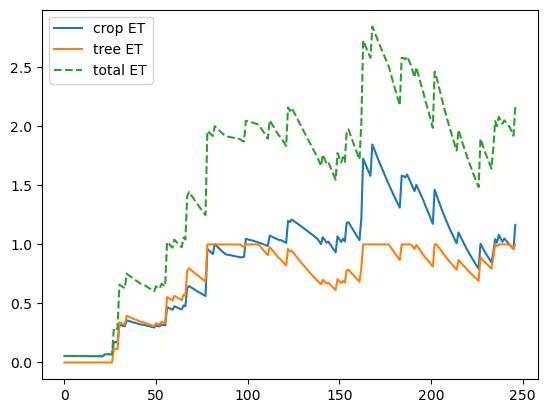

In [164]:
# %% Initialize Climate
climate = Climate()

# %% Initialize Soil
soil = Soil(texture="loam")

# %% Initialize Crop (unchanged)
crop = Crop(soil=soil)

tree_params = dict(
    Zr=1500,
    T_MAX=1.0,
    sw_MPa=-2.0,
    s_star_MPa=-0.2,
    kc=1.0
)

tree = Tree(soil=soil, **tree_params)


# %% Initialize Model
model = TreeCropModel(crop=crop, tree=tree, climate=climate, soil=soil)

# %% Run
model.run()

# %% Output
output = model.output()

# %% Plot (two lines)
output["ET_crop"].plot(label="crop ET")
output["ET_tree"].plot(label="tree ET")
# optional:
output["ET"].plot(label="total ET", linestyle="--")

plt.legend()
plt.show()


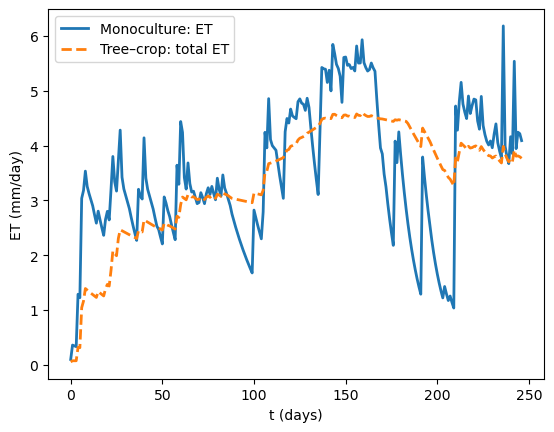

In [165]:
np.random.seed(150)
# climate = Climate()
# scale storm depth

# create default climate
default_climate = Climate()

# scale storm depth
climate = Climate(
    alpha_r=[a * 1.5 for a in default_climate.alpha_r],
    lambda_r=default_climate.lambda_r,
    ET_max=6.5
)

# increases frequency
climate = Climate(
    alpha_r=[a * 1.5 for a in default_climate.alpha_r],
    lambda_r=[l * 1.3 for l in default_climate.lambda_r],
    ET_max=6.5
)

# --- Monoculture (original model) ---
soil_mono = Soil(texture="loam")
crop_mono = Crop(soil=soil_mono)
soil_mono.set_nZr(crop_mono)
mono = CropModel(crop=crop_mono, climate=climate, soil=soil_mono)
mono.run()
out_mono = mono.output()

# --- Tree-crop model---
soil_tc = Soil(texture="loam")
crop_tc = Crop(soil=soil_tc)
tree = Tree(soil=soil_tc, Zr=1500, T_MAX=1.5, sw_MPa=-2.0, s_star_MPa=-0.2, kc=1.0)

tc = TreeCropModel(crop=crop_tc, tree=tree, climate=climate, soil=soil_tc)
tc.run()
out_tc = tc.output()

# --- Plot ---
ax = out_mono["ET"].plot(label="Monoculture: ET", linewidth=2)
out_tc["ET"].plot(ax=ax, label="Tree–crop: total ET", linestyle="--", linewidth=2)


ax.set_xlabel("t (days)")
ax.set_ylabel("ET (mm/day)")
ax.legend()
plt.show()


In [166]:
climate.rainfall.mean()

5.269264676264371

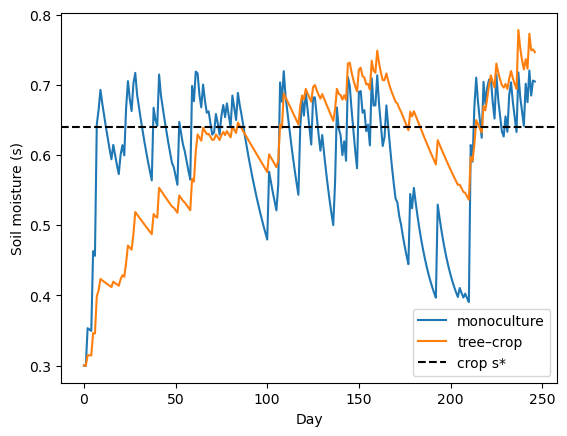

In [167]:
plt.figure()
out_mono["s"].plot(label="monoculture")
out_tc["s"].plot(label="tree–crop")

plt.axhline(crop.s_star, color="k", linestyle="--", label="crop s*")

plt.ylabel("Soil moisture (s)")
plt.xlabel("Day")
plt.legend()
plt.show()


In [168]:
(out_tc["s"] < crop.s_star).mean()


0.5587044534412956

In [169]:
def run_one_season(model_cls, soil_cls, crop_cls, climate_obj, *,
                   texture="loam", lgp=180,
                   planting_date=100, t_before=60, t_after=7, s0=0.3,
                   tree_params=None):

    soil = soil_cls(texture=texture)
    crop = crop_cls(soil=soil)
    crop.lgp = lgp

    if tree_params is None:
        soil.set_nZr(crop)
        model = model_cls(crop=crop, climate=climate_obj, soil=soil)
    else:
        tree = Tree(soil=soil, **tree_params)
        model = model_cls(crop=crop, tree=tree, climate=climate_obj, soil=soil)

    model.run(s0=s0, planting_date=planting_date, t_before=t_before, t_after=t_after)
    return crop, model.output()


In [170]:
def season_metrics(crop, df, lgp, y_max=4680):
    avg_stress, dyn_stress, yld = crop.calc_dstress(
        s=df["s"].values,
        stress=df["stress"].values,
        Y_MAX=y_max
    )
    rf = df["R"].sum()
    return avg_stress, dyn_stress, yld, rf



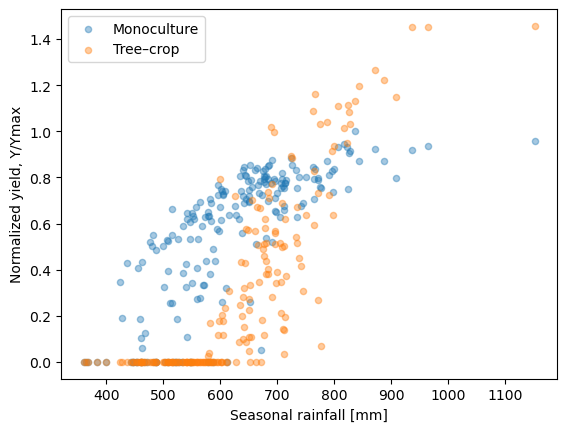

In [171]:
def simulate_systems(n_sims, *, lgp=180, texture="loam", seed=123):
    rng = np.random.default_rng(seed)

    rows_mono, rows_tree = [], []
    outputs_mono, outputs_tree = [], []

    tree_params = dict(
        Zr=1500,
        T_MAX=1.0,
        sw_MPa=-2.0,
        s_star_MPa=-0.1,
        kc=1.0
    )

    for i in range(n_sims):
        np.random.seed(rng.integers(0, 2**32 - 1, dtype=np.uint32).item())
        climate=Climate()
        # climate = Climate( #edit this!
        # alpha_r=[a * 1.5 for a in default_climate.alpha_r],
        # lambda_r=[l * 1.3 for l in default_climate.lambda_r],
        # ET_max=6.5
        # )

        # --- monoculture
        crop_m, out_m = run_one_season(
            CropModel, Soil, Crop, climate,
            texture=texture, lgp=lgp
        )
        a, d, y, rf = season_metrics(crop_m, out_m, lgp)
        rows_mono.append(dict(Sim=i, AvgStress=a, DynamicStress=d, Yield=y, RF=rf))
        outputs_mono.append(out_m)

        # --- tree-crop
        crop_t, out_t = run_one_season(
            TreeCropModel, Soil, Crop, climate,
            texture=texture, lgp=lgp,
            tree_params=tree_params
        )
        a, d, y, rf = season_metrics(crop_t, out_t, lgp)
        rows_tree.append(dict(Sim=i, AvgStress=a, DynamicStress=d, Yield=y, RF=rf))
        outputs_tree.append(out_t)

    return pd.DataFrame(rows_mono), pd.DataFrame(rows_tree), outputs_mono, outputs_tree

def fig8_compare(df_mono, df_tree):
    df_mono = df_mono.copy()
    df_tree = df_tree.copy()

    df_mono["Yield_norm"] = df_mono["Yield"] / df_mono["Yield"].max()
    df_tree["Yield_norm"] = df_tree["Yield"] / df_tree["Yield"].max()

    plt.figure(figsize=(6,4))
    plt.scatter(df_mono["RF"], df_mono["Yield_norm"], alpha=0.5, s=12, label="Monoculture")
    plt.scatter(df_tree["RF"], df_tree["Yield_norm"], alpha=0.5, s=12, label="Tree–crop")

    plt.ylim(-0.05, 1.05)
    plt.ylabel(r"Normalized yield, $Y/Y_{max}$")
    plt.xlabel("Seasonal rainfall [mm]")
    plt.legend()
    plt.show()

df_mono, df_tree, outs_m, outs_t = simulate_systems(n_sims=200, lgp=180, seed=42)
df_mono["Yield_norm"] = df_mono["Yield"] / df_mono["Yield"].max()
df_tree["Yield_norm"] = df_tree["Yield"] / df_mono["Yield"].max()  # normalize to mono Ymax
plt.figure()
plt.scatter(df_mono.RF, df_mono.Yield_norm, alpha=0.4, s=20, label="Monoculture")
plt.scatter(df_tree.RF, df_tree.Yield_norm, alpha=0.4, s=20,
            label="Tree–crop")
plt.xlabel("Seasonal rainfall [mm]")
plt.ylabel("Normalized yield, Y/Ymax")
plt.legend()
plt.show()


In [172]:
df_mono["Yield"].describe()


count     200.000000
mean     1582.730820
std       846.921348
min         0.000000
25%      1063.465203
50%      1879.418117
75%      2236.206615
max      2843.589752
Name: Yield, dtype: float64

In [173]:
out_tc["s"]


0      0.300000
1      0.299920
2      0.314688
3      0.314577
4      0.314465
         ...   
242    0.723205
243    0.772975
244    0.749304
245    0.750592
246    0.746726
Name: s, Length: 247, dtype: float64

In [236]:
rain_regimes = {
    "few_intense": dict(alpha_scale=1.5, lambda_scale=0.67),
    "baseline":    dict(alpha_scale=1.0, lambda_scale=1.0),
    "many_small":  dict(alpha_scale=0.67, lambda_scale=1.5),
}

def simulate_systems_by_regime(n_sims, *, lgp=180, texture="loam", seed=123):
    rng = np.random.default_rng(seed)
    default_climate = Climate()

    rows = []

    for regime, scales in rain_regimes.items():
        for i in range(n_sims):
            np.random.seed(rng.integers(0, 2**32 - 1, dtype=np.uint32).item())

            climate = Climate(
                alpha_r=[a * scales["alpha_scale"] for a in default_climate.alpha_r],
                lambda_r=[l * scales["lambda_scale"] for l in default_climate.lambda_r],
                ET_max=default_climate.ET_max
            )

            # monoculture
            crop_m, out_m = run_one_season(
                CropModel, Soil, Crop, climate,
                texture=texture, lgp=lgp
            )
            a, d, y, rf = season_metrics(crop_m, out_m, lgp)
            rows.append(dict(
                Regime=regime, System="Mono", RF=rf, Yield=y
            ))

            # tree–crop
            crop_t, out_t = run_one_season(
                TreeCropModel, Soil, Crop, climate,
                texture=texture, lgp=lgp,
                tree_params=tree_params
            )
            a, d, y, rf = season_metrics(crop_t, out_t, lgp)
            rows.append(dict(
                Regime=regime, System="TreeCrop", RF=rf, Yield=y
            ))

    return pd.DataFrame(rows)


df = simulate_systems_by_regime(n_sims=200, lgp=180, seed=42)
df_mono = df[df.System == "Mono"].copy()
df_tree = df[df.System == "TreeCrop"].copy()
Ymax = df_mono["Yield"].max()
df_mono["Yield_norm"] = df_mono["Yield"] / Ymax
df_tree["Yield_norm"] = df_tree["Yield"] / Ymax


fig, axes = plt.subplots(
    1, 3, figsize=(12,4),
    sharex=True, sharey=True
)

regimes = ["few_intense", "baseline", "many_small"]

for ax, regime in zip(axes, regimes):
    m = (df_mono.Regime == regime)
    t = (df_tree.Regime == regime)

    ax.scatter(
        df_mono.loc[m, "RF"],
        df_mono.loc[m, "Yield_norm"],
        s=18, alpha=0.4,
        marker="o", label="Monoculture"
    )

    ax.scatter(
        df_tree.loc[t, "RF"],
        df_tree.loc[t, "Yield_norm"],
        s=18, alpha=0.4,
        marker="^", label="Tree–crop"
    )

    ax.set_title(regime.replace("_", " ").title())
    ax.set_xlabel("Seasonal rainfall [mm]")

axes[0].set_ylabel("Normalized yield, Y / Ymax (mono)")
axes[0].legend(frameon=False)

plt.tight_layout()
plt.show()



KeyError: 's'

Add stress_crop based on _s_after_tree in TreeCropModel (small change)!

Refinement probably want:

1. The right version for tree-crop water access maybe:

compute available water in the tree root zone and crop root zone

subtract T_tree from tree-zone storage first

then compute the remaining storage accessible to the crop

update s (or theta) consistently

Right now the tree increases the bucket depth because we set nZr using max(Zr_crop, Zr_tree). That’s consistent with a shared soil reservoir accessible to both.

but does “tree has deeper water” effect later, the next step is a 2-layer bucket:

shallow bucket accessible to crop + tree

deep bucket accessible only to tree

2. what is the outcome variable?

In [175]:
baseline_tree = dict(
    Zr=1500,
    T_MAX=1.0,
    sw_MPa=-2.0,
    s_star_MPa=-0.1,
    kc=1.0
)
param_grid = {
    "T_MAX": [0.5, 1.0, 2.0],
    "Zr":    [800, 1500, 2500],
    "kc":    [0.5, 1.0, 1.5],
}
def generate_climates(n_sims, seed=42):
    rng = np.random.default_rng(seed)
    climates = []
    for _ in range(n_sims):
        np.random.seed(rng.integers(0, 2**32 - 1))
        climates.append(Climate())
    return climates

def stress_sensitivity(param_name, values, climates, lgp=180):

    results = []

    for val in values:

        tree_params = baseline_tree.copy()
        tree_params[param_name] = val

        stresses = []

        for climate in climates:

            crop, out = run_one_season(
                TreeCropModel, Soil, Crop, climate,
                texture="loam", lgp=lgp,
                tree_params=tree_params
            )

            a, d, y, rf = season_metrics(crop, out, lgp)
            stresses.append(d)

        results.append({
            "param": param_name,
            "value": val,
            "mean_stress": np.mean(stresses),
            "std_stress": np.std(stresses)
        })

    return pd.DataFrame(results)

climates = generate_climates(n_sims=100, seed=42)

df_Tmax = stress_sensitivity("T_MAX", param_grid["T_MAX"], climates)
df_Zr   = stress_sensitivity("Zr", param_grid["Zr"], climates)
df_kc   = stress_sensitivity("kc", param_grid["kc"], climates)



In [176]:
df_kc

,param,value,mean_stress,std_stress
0,kc,0.5,0.687376,0.303748
1,kc,1.0,0.829663,0.231672
2,kc,1.5,0.929607,0.157455


# really doing a little comp here


to do
1. darcy's law instead of whatever storage situtation rn


In [227]:
class TreeCropModel:
    def __init__(self, soil=None, climate=None, crop=None, tree=None):
        self.soil = soil
        self.crop = crop
        self.tree = tree
        self.climate = climate

        # --- Two-layer storage ---
        # Top layer = crop rooting depth
        self.nZr_top = soil.set_nZr(self.crop)

        # Deep layer = additional tree rooting depth
        class _Tmp: pass
        tmp = _Tmp()
        tmp.Zr = max(self.tree.Zr - self.crop.Zr, 0.0)
        self.nZr_deep = soil.set_nZr(tmp) if tmp.Zr > 0 else 0.0


    def pre_allocate(self):
        self.R = zeros(self.n_days)

        # --- Two soil moisture states ---
        self.s_top = zeros(self.n_days + 1)
        self.s_deep = zeros(self.n_days + 1)

        self.ET = zeros(self.n_days)
        self.I = zeros(self.n_days)
        self.E = zeros(self.n_days)
        self.T = zeros(self.n_days)
        self.L = zeros(self.n_days)
        self.Q = zeros(self.n_days)
        self.dos = zeros(self.n_days)
        self.dsdt = zeros(self.n_days)
        self.LAI = zeros(self.n_days)
        self.kc = zeros(self.n_days)
        self.stress = zeros(self.n_days)

        self.T_tree = zeros(self.n_days)
        self.ET_crop = zeros(self.n_days)
        self.ET_tree = zeros(self.n_days)


    def run(self, do_output=False, s0=0.3, planting_date=100, t_before=60, t_after=7):
        self.planting_date = planting_date
        self.n_days = t_before + self.crop.lgp + t_after
        self.pre_allocate()

        self.doy_start = self.planting_date - t_before
        if self.doy_start <= 0:
            self.doy_start = 365 + self.doy_start

        doy = np.arange(self.doy_start, self.doy_start + self.n_days)
        while (doy - 365 > 0).any():
            doy = doy - 365 * ((doy - 365) > 0)

        for t in range(self.n_days):
            self.R[t] = self.climate.rainfall[doy[t]-1]
        self.doy = doy

        # --- Initial conditions ---
        self.s_top[0] = s0
        self.s_deep[0] = 0.0 # tree starts with no seperate water

        dos = 0
        planted = False

        for t in range(self.n_days):

            # ---------------------------
            # Phenology
            # ---------------------------
            if self.doy[t] == self.planting_date:
                planted = True
            if planted:
                dos += 1

            self.dos[t] = dos
            self.kc[t] = self.crop.calc_kc(dos)
            self.LAI[t] = self.crop.calc_LAI(self.kc[t])

            # ---------------------------
            # Runoff (based only on top layer)
            # ---------------------------
            self.Q[t] = self.soil.calc_Q(self.s_top[t], units="mm/day")

            # ---------------------------
            # Interception
            # ---------------------------
            self.I[t] = min(self.crop.calc_I(self.LAI[t]), self.R[t])
            rainfall = max(self.R[t] - self.I[t], 0.0)

            # ---------------------------
            # Infiltration into top layer
            # ---------------------------
            s_top = self.s_top[t]
            s_deep = self.s_deep[t]

            # Add rainfall minus runoff
            water_input = rainfall - self.Q[t]
            s_top += water_input / self.nZr_top

            # Cascade to deep layer if top exceeds saturation
            if s_top > 1.0:
                excess_mm = (s_top - 1.0) * self.nZr_top
                s_top = 1.0

                if self.nZr_deep > 0:
                    s_deep += excess_mm / self.nZr_deep
                else:
                    self.L[t] += excess_mm

            # ---------------------------
            # Tree uptake (top-first, then deep)
            # ---------------------------
            s_eff_tree_top = s_top
            T_tree_top_pot = self.tree.calc_T(s_eff_tree_top)

            # Extract from top layer first
            T_tree_top = min(T_tree_top_pot, s_top*self.nZr_top)
            s_top -= T_tree_top / self.nZr_top

            # Pull from deep if top isn't enough
            remaining_tree_demand = T_tree_top_pot - T_tree_top
            if remaining_tree_demand > 0 and self.nZr_deep > 0:
                T_tree_deep = min(remaining_tree_demand, s_deep*self.nZr_deep)
                s_deep -= T_tree_deep / self.nZr_deep
                T_tree_top += T_tree_deep

            # Final actual tree transpiration
            T_tree_actual = T_tree_top
            self.T_tree[t] = T_tree_actual


            # ---------------------------
            # Crop ET (top layer only)
            # ---------------------------
            s_eff_crop = max(s_top, 0.0)

            self.T[t] = self.crop.calc_T(s_eff_crop, LAI=self.LAI[t])
            self.E[t] = self.climate.calc_E(s_eff_crop, LAI=self.LAI[t], sh=self.soil.sh)

            sf = shade_factor(self.tree.calc_LAI())
            self.E[t] *= sf
            self.T[t] *= sf

            self.stress[t] = self.crop.calc_stress(s_eff_crop)

            # Remove crop ET from top
            ET_crop_mm = self.E[t] + self.T[t]
            available_top_mm = s_top * self.nZr_top
            ET_crop_mm = min(ET_crop_mm, available_top_mm)

            s_top -= ET_crop_mm / self.nZr_top

            self.ET_crop[t] = ET_crop_mm
            self.ET_tree[t] = self.T_tree[t]
            self.ET[t] = self.ET_crop[t] + self.ET_tree[t]

            # ---------------------------
            # Deep leakage
            # ---------------------------
            if s_deep > 1.0:
                excess_mm = (s_deep - 1.0) * self.nZr_deep
                s_deep = 1.0
                self.L[t] += excess_mm

            # ---------------------------
            # Save states
            # ---------------------------
            self.s_top[t+1] = max(s_top, 0.0)
            self.s_deep[t+1] = max(s_deep, 0.0)

            # Total storage change (diagnostic only)
            total_storage_today = (
                self.s_top[t] * self.nZr_top +
                self.s_deep[t] * self.nZr_deep
            )
            total_storage_next = (
                self.s_top[t+1] * self.nZr_top +
                self.s_deep[t+1] * self.nZr_deep
            )
            self.dsdt[t] = total_storage_next - total_storage_today

        if do_output:
            return self.output()


    def output(self):
        return DataFrame({
            "kc": self.kc,
            "LAI": self.LAI,
            "stress": self.stress,
            "R": self.R,
            "s_top": self.s_top[:-1],
            "s_deep": self.s_deep[:-1],
            "I": self.I,
            "E": self.E,
            "T_crop": self.T,
            "T_tree": self.T_tree,
            "ET_crop": self.ET_crop,
            "ET_tree": self.ET_tree,
            "ET": self.ET,
            "L": self.L,
            "dsdt": self.dsdt,
            "dos": self.dos,
            "doy": self.doy,
        })


In [234]:
np.random.seed(42)
climate = Climate()

# --- Monoculture
crop_m, out_m = run_one_season(
    CropModel, Soil, Crop, climate,
    texture="loam", lgp=180
)

# --- Tree–crop
tree_params = dict(
    Zr=1500,
    T_MAX=2.0,
    sw_MPa=-2.0,
    s_star_MPa=-0.1,
    kc=1.0
)

crop_t, out_t = run_one_season(
    TreeCropModel, Soil, Crop, climate,
    texture="loam", lgp=180,
    tree_params=tree_params
)


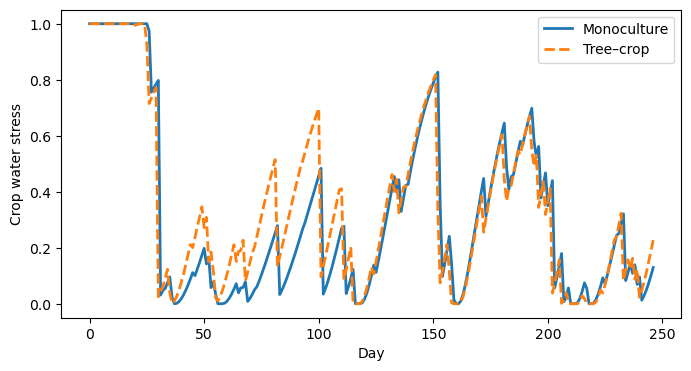

In [235]:
plt.figure(figsize=(8,4))

plt.plot(out_m["stress"], label="Monoculture", lw=2)
plt.plot(out_t["stress"], label="Tree–crop", lw=2, linestyle="--")

plt.xlabel("Day")
plt.ylabel("Crop water stress")
plt.legend()
plt.show()

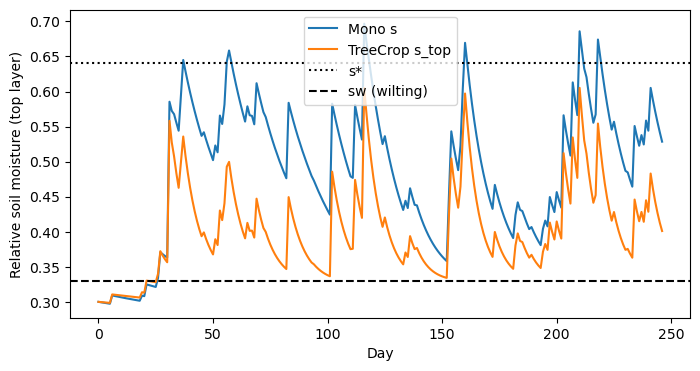

In [230]:
plt.figure(figsize=(8,4))

# Mono (single bucket)
plt.plot(out_m["s"], label="Mono s")

# Agroforestry (top layer only)
plt.plot(out_t["s_top"], label="TreeCrop s_top")

plt.axhline(crop.s_star, color="k", linestyle=":", label="s*")
plt.axhline(crop.sw, color="k", linestyle="--", label="sw (wilting)")

plt.xlabel("Day")
plt.ylabel("Relative soil moisture (top layer)")

plt.legend()
plt.show()


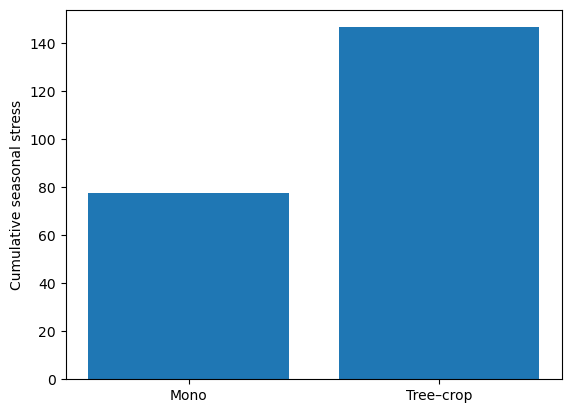

In [231]:
cum_stress_m = out_m["stress"].sum()
cum_stress_t = out_t["stress"].sum()

plt.bar(["Mono", "Tree–crop"],
        [cum_stress_m, cum_stress_t])
plt.ylabel("Cumulative seasonal stress")
plt.show()


In [232]:
print(out_t["stress"].sum())
print(out_m["stress"].sum())
# print(season_metrics(crop_t, out_t, 180))


146.477680975332
77.3178889561645


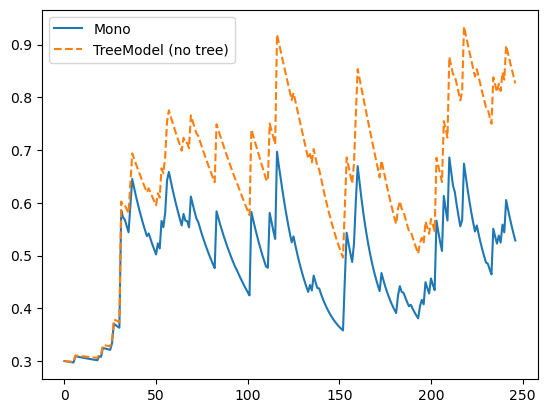

In [233]:
tree_params_no_tree = dict(
    Zr=1500,
    T_MAX=0.0,        # <- no transpiration
    sw_MPa=-2.0,
    s_star_MPa=-0.1,
    kc=0.0            # <- no canopy interception
)
crop_t0, out_t0 = run_one_season(
    TreeCropModel, Soil, Crop, climate,
    texture="loam", lgp=180,
    tree_params=tree_params_no_tree
)
plt.plot(out_m["s"], label="Mono")
plt.plot(out_t0["s_top"], "--", label="TreeModel (no tree)")
plt.legend()


In [159]:
out_t0["s"].describe()

count    247.000000
mean       0.491214
std        0.097765
min        0.297327
25%        0.427684
50%        0.510092
75%        0.564454
max        0.696722
Name: s, dtype: float64

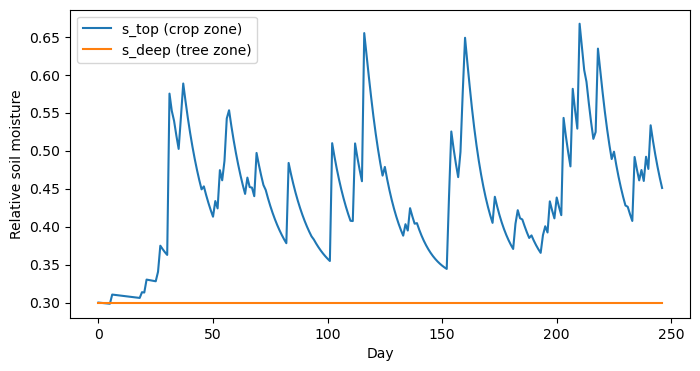

In [190]:
plt.figure(figsize=(8,4))

plt.plot(out_t["s_top"], label="s_top (crop zone)")
plt.plot(out_t["s_deep"], label="s_deep (tree zone)")

plt.xlabel("Day")
plt.ylabel("Relative soil moisture")
plt.legend()
plt.show()


In [161]:
diff = out_t0["s"] - out_m["s"]
print(diff.describe())


count    247.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: s, dtype: float64


Text(0.5, 1.0, 'TreeModel(no tree) - Mono soil moisture')

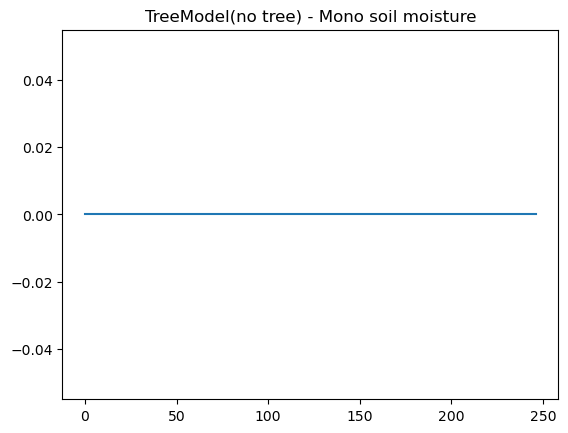

In [162]:
plt.plot(diff)
plt.title("TreeModel(no tree) - Mono soil moisture")


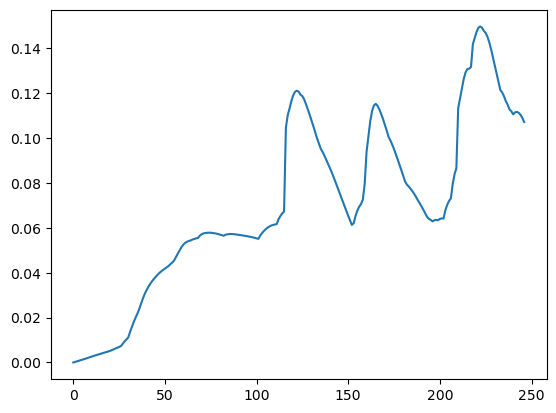

In [210]:
plt.plot(out_t["s_top"] - out_m["s"])
